# Exercises 7

## Exercise 7.1

In this simulation, forces are computed only up to a cutoff radius $R_C$ (in LJ units), rather than between all pairs of particles as would be ideal. This truncation introduces a systematic error in every quantity that depends on the interaction between particles (in our case, the potential energy $U$ and the pressure $P$) so we need to apply a tail correction to account for the contribution of forces beyond $R_C$​.

In general, the 3D ensemble average of any quantity $\langle A \rangle$ that depends on the pair distance $r$ can written as:
$$
\langle A \rangle = \frac{N^2}{2V} \int_0^{+\infty} A(r) 4 \pi r^2 g(r) \mathrm{d}r
$$
Where $N$ is the number of objects (particles) and $V$ is the volume. We will later denote the potential as $V_\text{LJ}(r)$

The simulation already computes the part of the integral from 0 to $R_C$. We need to reintroduce the tail $\int_{R_C}^{+\infty}[\ldots] \mathrm{d}r$.
For $r > R_C$ the particles are far enough apart that the radial distribution function can be approximated to one $g(r) \approx 1$, this approximation lets us compute the tail correction analytically.

### Potential Energy Correction
Applying this approximation to the potential energy (and using LJ units, $\varepsilon = \sigma = 1$):
$$
\frac{\langle U \rangle_\text{tail}}{N} \approx 2\pi \rho \int_{R_C}^{+\infty} \mathrm{d}r r^2 V_\text{LJ}(r) = \ldots = 8\pi\rho \left(\frac{1}{9 R_C^9} - \frac{1}{3 R_C^3}\right)
$$

### Pressure Correction
The same idea applies to the pressure, but we calculate the correction from the tail of the virial
$$
W = \sum_i\sum_{j < i}\vec f_{ij} \cdot \vec r_{ij}
$$
Using $\langle P \rangle_\text{tail} = \frac{\langle W \rangle_\text{tail}}{3V}$:
$$
\langle P \rangle_\text{tail} = - \frac{2\pi}{3}\rho^2 \int_{R_C}^{+\infty} \mathrm{d}r\,r^3 \frac{\mathrm{d}V_\text{LJ}(r)}{\mathrm{d} r} g(r) \approx - \frac{2\pi}{3}\rho^2 \int_{R_C}^{+\infty} \mathrm{d}r\,r^3 \frac{\mathrm{d}V_\text{LJ}(r)}{\mathrm{d} r} = \ldots = 32 \pi \rho^2 \left(\frac{1}{9 R_C^9} - \frac{1}{6 R_C^3} \right) 
$$

## Exercise 7.2

We are asked to plot the autocorrelation and the statistical uncertainty as a function of the block size.

### Equilibration

In the simulation both Monte Carlo (NVT) and Molecular Dynamics (NVE) need a bit of settling time before reaching our physical system of interest. 

In particular Monte Carlo will not conserve the starting temperature value, to reach the desired temperature $T^* = 1.1$ we have to start the system at the temperature $T \approx 2.0$.

In the following figures I will show the Potential Energy after some steps to evaluate the equilibration time.

In [1]:
# Imports
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt

import scienceplots

plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

plt.rcParams["figure.dpi"] = 300

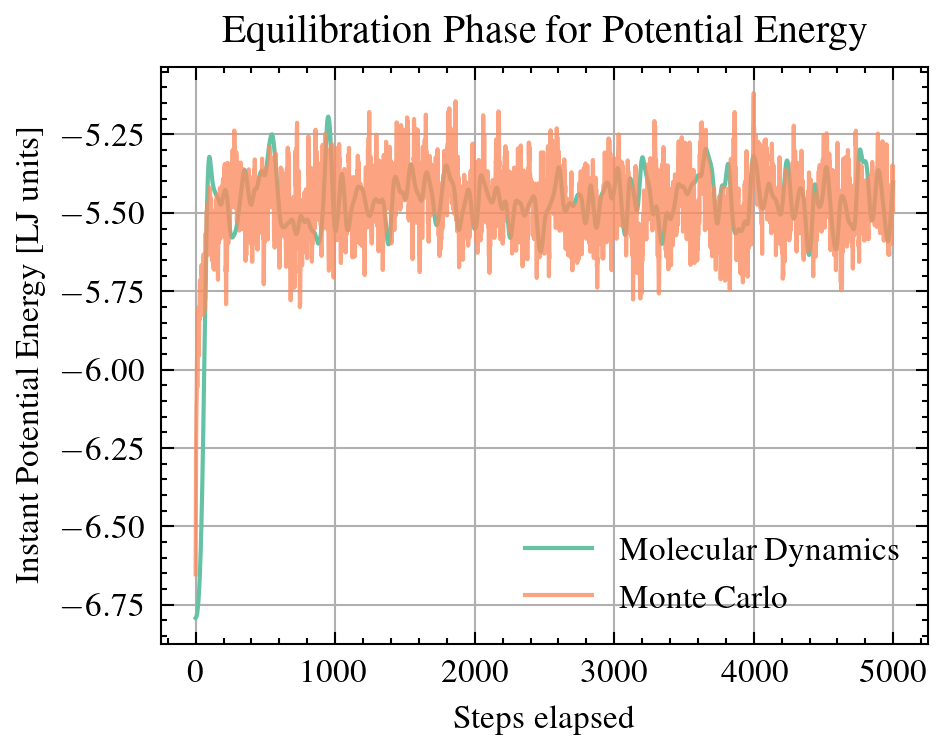

In [2]:
# Load data
U_MD = np.loadtxt("./Data/Equilibration/MD/potential_energy.dat")

U_MC = np.loadtxt("./Data/Equilibration/MC/potential_energy.dat")

# Plot
plt.plot(U_MD[:, 1], label="Molecular Dynamics")
plt.plot(U_MC[:, 1], label="Monte Carlo", alpha=0.8)

plt.title("Equilibration Phase for Potential Energy")
plt.xlabel("Steps elapsed")
plt.ylabel(f"Instant Potential Energy [LJ units]")

plt.legend()
plt.grid()

plt.show()

As we can see after around 100 steps both systems reached a costant energy (except for small fluctuations). 

For the following simulations I decided to add 1000 steps (just to be safe) of burn-in, before taking any measurement. 

### Autocorrelation
Since both Monte Carlo and Molecular Dynamics are methods dependent from the previous step(s) we must evaluate autocorrelation time before using datablocking.

The autocorrelation is defined as:
$$
\chi(\tau) = \frac{\langle m(t)m(t + \tau) \rangle -\langle m \rangle^2}{\sigma_m^2}
$$
Where $\tau$ is the size of the window we are interested to compute. Since we are interested in studing the size of the window, we have to compute this formula for different values of $\tau$.

To compute more efficiently the autocorrelation we can substitute $\tilde m(t) = m(t) - \langle m \rangle$, in this way $\langle \tilde m(t) \tilde m(t + \tau)\rangle = \langle m(t)m(t + \tau) \rangle -\langle m(t) \rangle^2$ and $\sigma_m^2 = \langle \tilde m^2 \rangle$. So previous formula becomes:

$$
\chi(\tau) = \frac{\langle \tilde m(t) \tilde m(t + \tau)\rangle}{\langle \tilde m^2 \rangle}
$$

Note: both formulas are valid under the assumption that the number of samples $N$ is much grater than the window size $N \gg \tau$.

In the following figure there is plotted the autocorrelation for the potential energy per particle.

In [3]:
def autocorr(x: np.ndarray[float], tau_list: np.ndarray[int]) -> np.ndarray[float]:
    """Returns an array of autocorrelation values for each tau in tau_list"""
    x = x - x.mean()

    chi = np.empty_like(tau_list, dtype=float)

    for i, tau in enumerate(tau_list):
        chi[i] = np.mean(x[:-tau] * x[tau:]) / np.mean(x**2)

    return chi

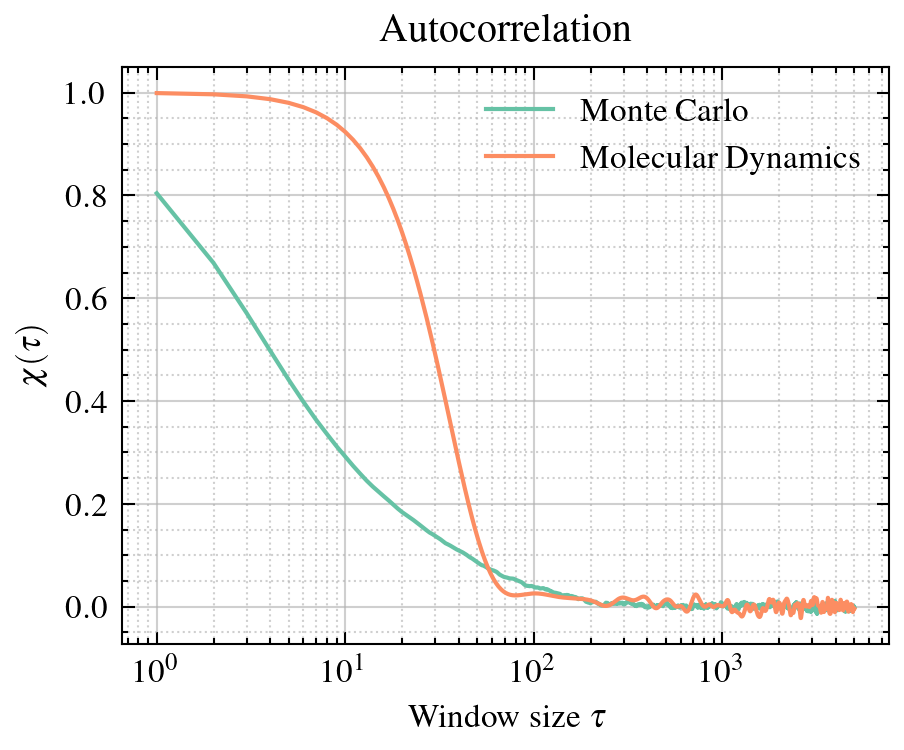

In [4]:
# Load data
U_MC = np.loadtxt("./Data/AutoCorrelation/MC/potential_energy.dat")
U_MC = U_MC[:, 1]  # keep only current potential energy

U_MD = np.loadtxt("./Data/AutoCorrelation/MD/potential_energy.dat")
U_MD = U_MD[:, 1]  # keep only current potential energy

tau = np.linspace(1, 5000, 5000, dtype=int)  # window size

# Calculate autocorrelation
auto_MC = autocorr(U_MC, tau)
auto_MD = autocorr(U_MD, tau)

# Plot
plt.plot(tau, auto_MC, label="Monte Carlo")
plt.plot(tau, auto_MD, label="Molecular Dynamics")

plt.title("Autocorrelation")
plt.xlabel(r"Window size $\tau$")
plt.ylabel(r"$\chi(\tau)$")

plt.legend()
plt.grid(True, alpha=0.6)
plt.grid(True, which="minor", ls=":", alpha=0.6)

plt.xscale("log")

plt.show()

From the figure we can see that the autocorrelation drops to near 0 before 100 steps for both Monte Carlo and Molecular Dynamics. If we use blocks of 100 steps or more we can consider them independent from each other.

### Statistical uncertainty and steps per block.

With the same data as the previous point we can also calculate the statistical uncertainties as a function of the steps per block $L$. In this way we can evaluate the smallest size of blocks that gives us a meaningful block uncertainty.

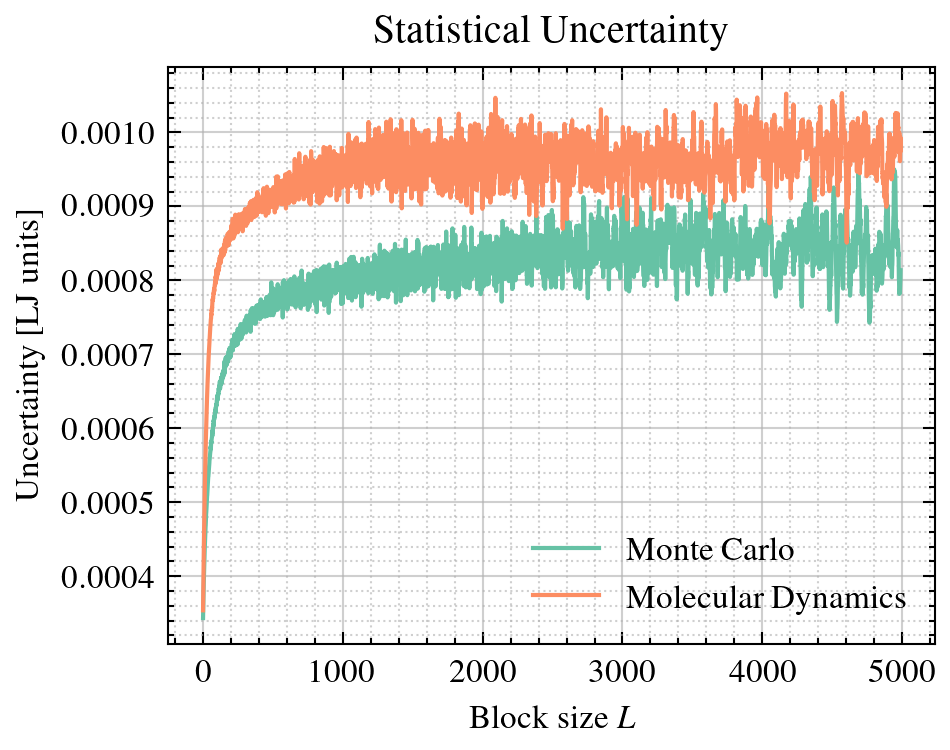

In [5]:
# Calculate errors for different block sizes
L = np.arange(10, 5000)
errors_MC = np.zeros_like(L, dtype=float)
errors_MD = np.zeros_like(L, dtype=float)

for i, l in enumerate(L):
    means_MC = (U_MC[U_MC.size % l :]).reshape(-1, l).mean(axis=1)
    means_MD = (U_MD[U_MD.size % l :]).reshape(-1, l).mean(axis=1)

    errors_MC[i] = means_MC.std() / np.sqrt(means_MC.size)
    errors_MD[i] = means_MD.std() / np.sqrt(means_MD.size)

# Plot
plt.plot(errors_MC, label="Monte Carlo")
plt.plot(errors_MD, label="Molecular Dynamics")

plt.title("Statistical Uncertainty")
plt.ylabel("Uncertainty [LJ units]")
plt.xlabel("Block size $L$")

plt.legend()
plt.grid(True, alpha=0.6)
plt.grid(True, which="minor", ls=":", alpha=0.6)

plt.show()

We can see that after around 1000 steps variance estimates become reliable, on the opposite if we take blocks with less steps we can end up with variances too little for our estimates. 

We can also note that after 1000 steps increasing the block size won't give us lower variances. After that threshold increasing the number of blocks gives the same result as increasing the block size, specifically the variance will decrease with $\sqrt{n_\text{steps}}$.

## Exercise 7.3

We are asked to include the radial distribution function $g(r)$ in our code. 

To compute it, we start by considering all pairwise distances between particles and sorting them into bins of width $\Delta r$. Each bin simply counts how many have a separation falling between $r$ and $r + \Delta r$. This raw count cannot be used as-is: it needs to be normalized to account for the fact that spherical shells at larger $r$ naturally contain more volume (and so more pairs), and for the overall particle density of the system. 

The normalization factor is the inverse of $\rho N \Delta V(r)$, where $\rho$ is the numerical density, $N$ is the total number of particles and $\Delta V(r)$ is the shell volume, which corresponds to the difference between two spheres of radii $r + \Delta r$ and $r$, so $\Delta V = \frac{4}{3}\pi \big((r+\Delta r)^3 - r^3\big)$. Dividing each bin's count by this factore yields a properly scaled $g(r)$, which represents the expected number of particles at distance $r$ relative to any reference particle.

Note: since forces are only computed up to the cutoff radius $R_C$, any distance beyond $R_C$ has no physical meaning in our simulation. For this reason, bins are not computed for $r > R_C$.

A plot of $g(r)$ is shown in the next exercise.

## Exercise 7.4

We are asked to make two simulations, one with MC and one with MD, then show some figures of the potential energy per particle $U/N$, the pressure $P$ and the radial distribution function $g(r)$.

For the simulations I used 1000 steps per block and a total of 100 blocks.

In [6]:
def plot_data_blocking(
    files: list[str],
    labels: list[str],
    ylabel: str,
    title: str,
) -> None:
    """Plots the datablocking for multiple files"""
    plt.figure()

    for file, label in zip(files, labels):
        # load file
        data = np.loadtxt(file)
        x_blocks = np.arange(len(data)) + 1

        # plot
        plt.errorbar(
            x_blocks,
            data[:, 2],  # blocking average
            data[:, 3],  # blocking error
            label=label,
            alpha=0.7,
        )

    plt.xlabel("Block Number")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.7)
    plt.legend()

    plt.show()

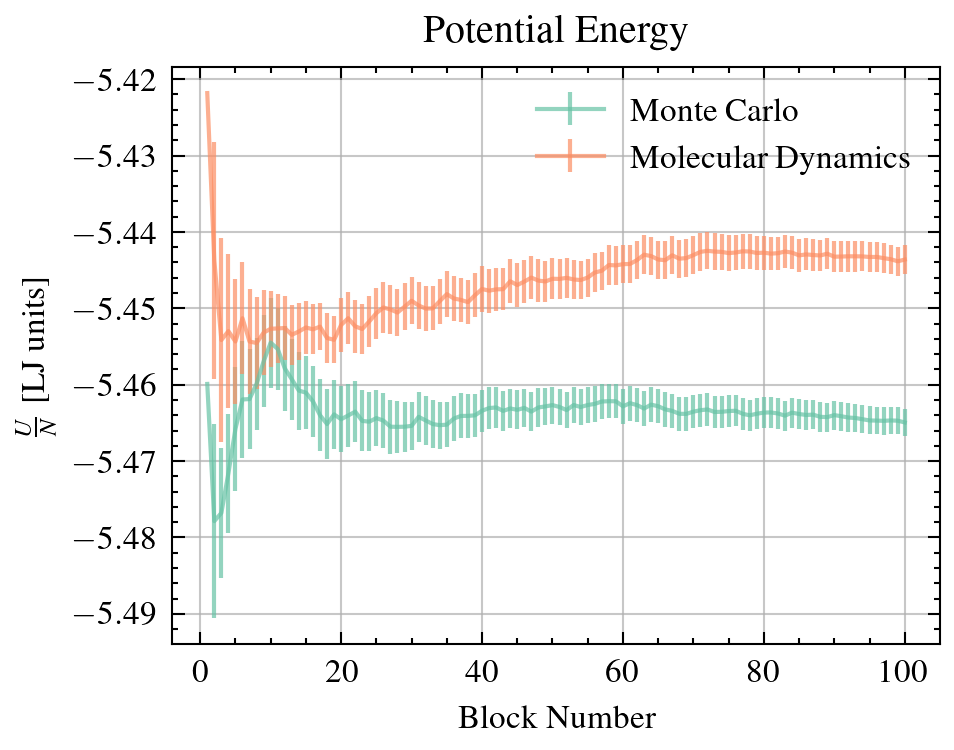

In [7]:
plot_data_blocking(
    files=[
        "./Data/GofR/MC/potential_energy.dat",
        "./Data/GofR/MD/potential_energy.dat",
    ],
    labels=["Monte Carlo", "Molecular Dynamics"],
    ylabel=r"$\frac{U}{N}$ [LJ units]",
    title="Potential Energy",
)

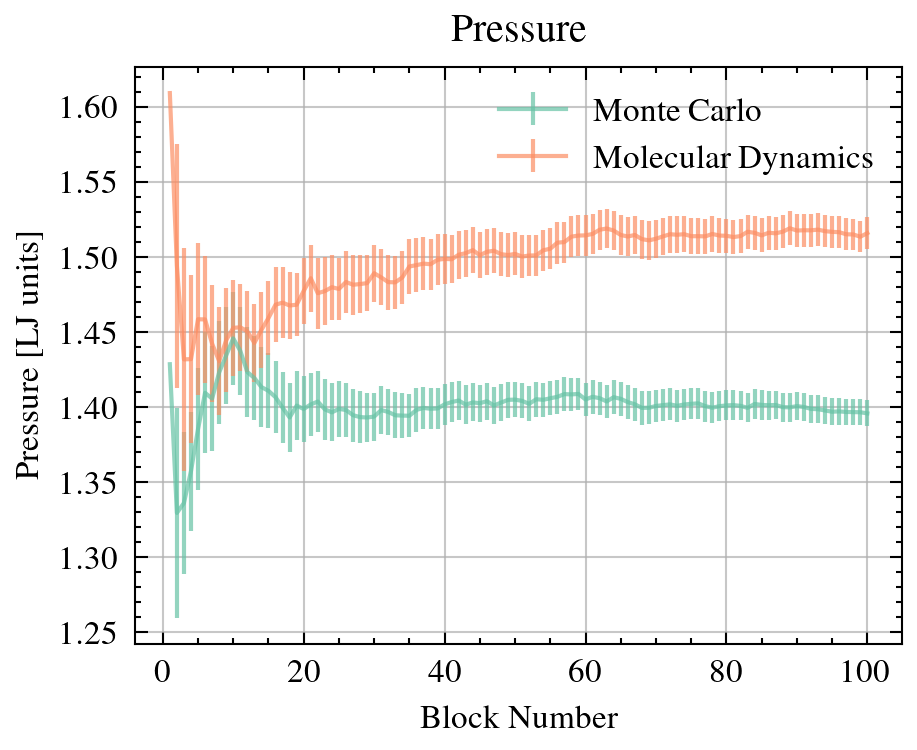

In [8]:
plot_data_blocking(
    files=[
        "./Data/GofR/MC/pressure.dat",
        "./Data/GofR/MD/pressure.dat",
    ],
    labels=["Monte Carlo", "Molecular Dynamics"],
    ylabel="Pressure [LJ units]",
    title="Pressure",
)

We can see that the two simulations give statistically incompatible results.

This is unexpected, since the NVE (MD) and NVT (MC) ensembles should, in principle, produce equivalent averages. However, this equivalence only holds strictly in the thermodynamic limit. Here we are simulating a system of just 108 particles, and although periodic boundary conditions help approximate the thermodynamic limit, some finite-size effects inevitably remain and these are likely responsible for the discrepancy we observe.

Also note that for exercise 7.2 we used $T=2.0$ to obtain $T^* \approx 1.1$, but with this starting condition the temperature still fluctuates around $T = 1.12$, which is not exactly $1.1$. This difference accounts for $\Delta P = \rho \Delta T \approx 2%$ error on $P$ for molecular dynamics, which is still too little to explain, by itself, the discrepancy in pressure between NVE and NVT.

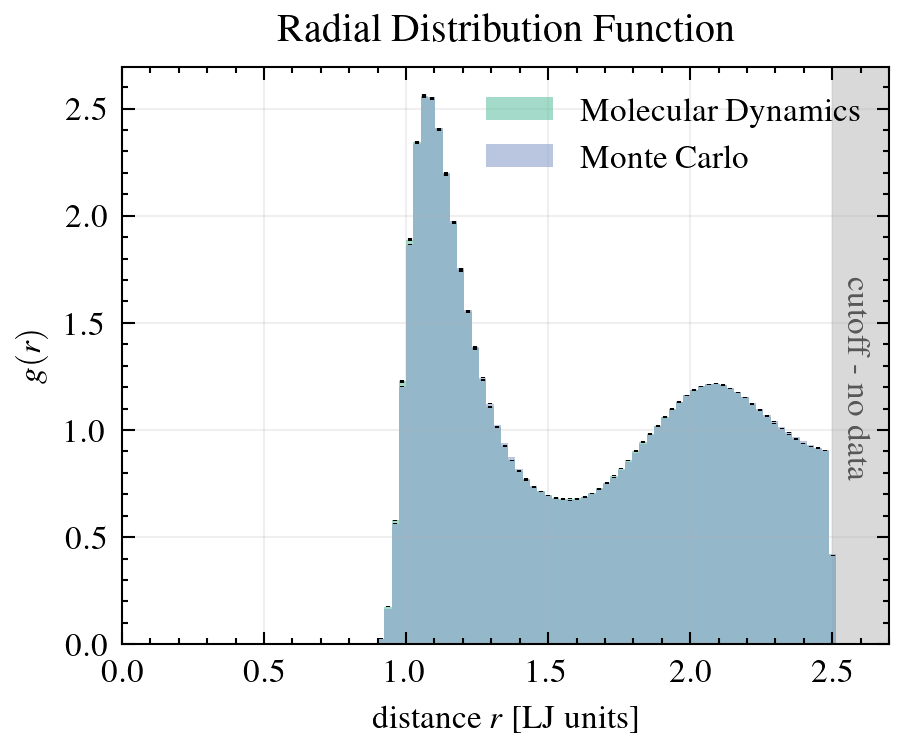

In [9]:
# Load data
gofr_MD = np.loadtxt("./Data/GofR/MD/gofr.dat")
gofr_MC = np.loadtxt("./Data/GofR/MC/gofr.dat")

# cutoff area
plt.axvspan(2.5, 2.7, color="0.85", lw=0)
plt.text(2.53, 0.8, "cutoff - no data", rotation=-90, alpha=0.6)

# histograms
plt.bar(
    gofr_MD[:, 0],
    gofr_MD[:, 1],
    width=gofr_MD[1, 0],
    yerr=gofr_MD[:, 2],
    label="Molecular Dynamics",
    alpha=0.6,
    align="edge",
)
plt.bar(
    gofr_MC[:, 0],
    gofr_MC[:, 1],
    width=gofr_MC[1, 0],
    yerr=gofr_MC[:, 2],
    label="Monte Carlo",
    alpha=0.6,
    align="edge",
    color="C2",
)

# style
plt.xlim(0, 2.7)

plt.xlabel(r"distance $r$ [LJ units]")
plt.ylabel(r"$g(r)$")

plt.title("Radial Distribution Function")

plt.legend()
plt.grid(True, alpha=0.2)

plt.show()

We observe that no particle pairs occur below approximately $r \leq 0.9$ (in LJ units), which is consistent with the strong short-range repulsion of the Lennard-Jones potential. The first peak of $g(r)$ appears near $r = 1.1$, corresponding to the equilibrium separation where the potential energy is minimized. Beyond this first shell, the distribution becomes more diffuse, with fewer particles found in the range $1.1$–$2.2$.

A second, weaker maximum then emerges around $r = 2.2$. This can be understood as a second-shell effect: particles sitting at $r = 1.1$ from our reference particle will themselves have neighbors at roughly $r = 1.1$ from them, which places those neighbors at approximately $r = 2.2$ from the original reference particle.

Following this reasoning, we would expect a series of increasingly weaker peaks at $r = 3.3$, $r = 4.4$, and so on, each corresponding to a further shell of neighbors. For $r \gg 1$, we expect $g(r) \approx 1$, since the correlation between two sufficiently distant particles vanishes.